# Configuración 4: 1D-CNN (a) + PINN (b) + predictor multi-paso (c) + autoatención (d)

**Anexo de código del TFM.** Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019).
Carlos J. Bravo I.

Las Configuraciones 2 y 3 son ramas paralelas desde la 1: añaden respectivamente el predictor
multi-paso y la ponderación aprendida sobre la secuencia de ciclos. La Configuración 4 las junta, y
con ella el conjunto queda cerrado. Las cuatro se obtienen cruzando dos decisiones binarias, el motor
de extrapolación y el modo de resumir el latente:

| | resumen por media | resumen ponderado |
|---|---|---|
| extrapolación analítica | Configuración 1 (a+b) | Configuración 3 (a+b+d) |
| integración paso a paso | Configuración 2 (a+b+c) | **Configuración 4 (a+b+c+d)** |

Disponerlas así permite separar lo que aporta cada componente por su cuenta de lo que aportan al
combinarse, que es lo único que ninguna configuración aislada puede dar. La cuestión propia de esta
configuración no es cuánto puntúa, sino si los dos componentes aportan juntos algo que no aporten por
separado.

Todo lo demás se hereda sin cambios de la Configuración 1: el preprocesado, el protocolo, la pérdida,
los hiperparámetros físicos y la cota de extrapolación.

## Contenido

| Apartado | Contenido |
|---|---|
| 1 | Las cuatro combinaciones |
| 2 | El modelo |
| 3 | Entrenamiento e inferencia |
| 4 | La tabla de contrastes |
| 5 | Aportación de cada componente y aportación conjunta |
| 6 | El recorrido entre semillas |
| 7 | Comparación con las Configuraciones 2 y 3 |
| 8 | El estudio de ablación completo |
| 9 | Conclusiones |
| 10 | Limitaciones |

Los pesos entrenados se guardan en `models/` y se reutilizan. Como la siembra está fijada, volver a entrenar solo cambia el tiempo de ejecución, no el resultado; `ENTRENAR_DE_NUEVO = True` en la primera celda de código lo rehace ignorando lo guardado.

### Arquitectura

El diagrama siguiente sitúa los componentes de esta configuración. Sobre la base de la Configuración 1 se añaden a la vez las dos piezas enmarcadas con trazo discontinuo: la autoatención (d) y el predictor multi-paso (c).

![Arquitectura de la Configuración 4](../docs/img/arquitectura_config4.png)

In [1]:
import sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
RAIZ = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "config1_cnn_pinn" / "model.py").is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from dataclasses import asdict

torch.set_num_threads(4)
pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

from config1_cnn_pinn.data import build_specimen_batches, load_labels
from config1_cnn_pinn.evaluate import ABLATION, n_observed_nonzero
from config1_cnn_pinn.physics import equivalent_stress_range, propagate_mm
from config1_cnn_pinn.train import Config, TRAIN_POOL, evaluate_ensemble, train_ensemble
from config2_rk4.integrator import integrate_block_rk4
from config2_rk4.retardation import integrate_with_retardation
from config4_completa.evaluate import COMBINACIONES, aportaciones, tabla_contrastes
from physics_calibration.data import load_curve
from physics_calibration.objectives import phm_penalty
from src.referencias_phm import PUBLICADO, PUESTOS, REPLICA

MARCA_DE_AGUA = "Carlos J. Bravo (2026)"


def marca_de_agua(fig, texto=MARCA_DE_AGUA):
    fig.text(0.995, 0.004, texto, fontsize=8, color="0.45", alpha=0.38,
             ha="right", va="bottom", fontweight="bold")
    return fig


WHEELER_P = 1.43
N_TANDAS = 4
INICIO = time.perf_counter()
for etiqueta, (motor, resumen) in COMBINACIONES.items():
    print(f"  {etiqueta:22s} extrapolación: {motor:12s} | resumen del latente: {resumen}")

from src.pesos_entrenados import cargar_o_entrenar, inventario

ENTRENAR_DE_NUEVO = False


  Config 1  (a+b)        extrapolación: analítica    | resumen del latente: media
  Config 2  (a+b+c)      extrapolación: paso a paso  | resumen del latente: media
  Config 3  (a+b+d)      extrapolación: analítica    | resumen del latente: ponderado
  Config 4  (a+b+c+d)    extrapolación: paso a paso  | resumen del latente: ponderado


## 1. Las cuatro combinaciones

La respuesta está acotada de antemano por lo que las configuraciones anteriores ya midieron, y eso es
una ventaja y no un inconveniente: permite usar el resultado como comprobación de que el conjunto de
contrastes está bien montado.

El predictor multi-paso no cambia la curva entregada, ni siquiera al levantar la cota de
extrapolación. Bajo amplitud constante la solución analítica es la solución exacta de la ecuación, y
en T8 la grieta avanza del orden de cinco centésimas de milímetro por bloque, demasiado poco para que
resolver segmento a segmento altere el resultado. Un componente que no cambia nada no puede aportar
nada al combinarse, de modo que su aportación conjunta con la ponderación aprendida sólo puede ser
nula. Medirla comprueba el montaje; el término que sí puede ser distinto de cero es el de la
ponderación, y el apartado 6 delimita cuánto de él es atribuible al componente.

## 2. El modelo

La Configuración 4 no introduce ninguna arquitectura nueva. Es la red de la Configuración 3, con su
codificador convolucional, su cabeza de grieta incremental y su cabeza de coeficiente con ponderación
aprendida sobre la secuencia de ciclos, acoplada al motor de extrapolación de la Configuración 2, que
integra numéricamente la ecuación diferencial sobre el bloque de carga real. No añade un solo
parámetro entrenable a la Configuración 3: lo que cambia ocurre después de la red, en cómo se propaga
la grieta desde el ancla.

## 3. Entrenamiento e inferencia

Se entrena un solo estimador por arquitectura y los motores de extrapolación se aplican después sobre
esos mismos pesos. Esa disposición es la que hace legítimo el contraste del motor: la diferencia entre
la Configuración 1 y la 2, o entre la 3 y la 4, no puede deberse a la variación entre semillas porque
comparten pesos. El contraste del resumen del latente sí cruza arquitecturas distintas, y por eso se
entrenan además cuatro tandas de semillas independientes de cada una.

In [2]:
cfg_media = Config(**ABLATION["Configuración 1 (1D-CNN + PINN)"])
cfg_pond = Config(**{**ABLATION["Configuración 1 (1D-CNN + PINN)"],
                     "architecture": "cnn_attention_pinn"})
COTA = cfg_media.cota_entrega_mm
ARQUITECTURAS = {"media": cfg_media, "ponderado": cfg_pond}

lotes = build_specimen_batches(load_labels(), cfg_media.m_exponent)
nombres = [n for n in TRAIN_POOL if n in lotes]
print(f"Configuración heredada: {cfg_media.epochs} épocas, dropout {cfg_media.dropout}, "
      f"peso de ancla x{cfg_media.anchor_weight:.0f}, m = {cfg_media.m_exponent:.2f}, "
      f"cota de entrega {COTA} mm")

modelos, tiempos = {}, {}
for resumen, cfg in ARQUITECTURAS.items():
    modelos[resumen], tiempos[resumen] = [], 0.0
    for k in range(N_TANDAS):
        c = Config(**{**asdict(cfg), "seed": k})
        tanda, segundos, procedencia = cargar_o_entrenar(
            f"config4/{resumen}_tanda{k}", c,
            lambda c=c: train_ensemble(c, lotes, nombres, n_seeds=5),
            forzar=ENTRENAR_DE_NUEVO, entrenados_sobre=nombres,
            notas=f"Resumen del latente {resumen}, tanda {k} de {N_TANDAS}, 5 semillas.")
        modelos[resumen].append(tanda)
        tiempos[resumen] += segundos
    print(f"  resumen {resumen:10s}: {N_TANDAS} tandas de 5 semillas en "
          f"{tiempos[resumen]:5.0f} s ({procedencia})")

Configuración heredada: 600 épocas, dropout 0.3, peso de ancla x48, m = 2.00, cota de entrega 7.24 mm


  resumen media     : 4 tandas de 5 semillas en   328 s (entrenado ahora)


  resumen ponderado : 4 tandas de 5 semillas en   478 s (entrenado ahora)


In [3]:
def ancla(mods, cfg, nombre):
    cur = load_curve(nombre)
    cyc, est, real, log_c = evaluate_ensemble(mods, lotes[nombre], cfg)
    nz = real > 0
    n_obs = n_observed_nonzero(nombre)
    return {"curva": cur, "ciclos_obs": cyc, "est_obs": est,
            "ancla_ciclo": float(cyc[nz][:n_obs][-1]), "ancla_mm": float(est[nz][:n_obs][-1]),
            "log_c": log_c, "d_sigma": equivalent_stress_range(cur.load_block, cfg.m_exponent)}


def entrega(d, cfg, motor, cota=None):
    cur = d["curva"]
    C_par, m = 10.0 ** d["log_c"], cfg.m_exponent
    cota = COTA if cota is None else cota
    objetivos = np.asarray(cur.cycles, dtype=float)
    pred = np.empty(len(objetivos))
    obs = set(d["ciclos_obs"].tolist())
    for i, cyc in enumerate(objetivos):
        if cyc <= d["ancla_ciclo"] and cyc in obs:
            pred[i] = d["est_obs"][d["ciclos_obs"] == cyc][0]
        else:
            dn = cyc - d["ancla_ciclo"]
            if motor == "analítica":
                pred[i] = propagate_mm(d["ancla_mm"], dn, C_par, m, d["d_sigma"], a_max_mm=cota)
            elif motor == "paso a paso":
                pred[i] = integrate_block_rk4(d["ancla_mm"], [dn], C_par, m, cur.load_block,
                                              a_max_mm=cota)[0, 0]
            else:
                pred[i] = integrate_with_retardation(d["ancla_mm"], [dn], C_par, m,
                                                     cur.load_block, WHEELER_P, a_max_mm=cota)[0]
    pred = np.maximum.accumulate(pred)
    return {"pred": pred,
            "penalizacion": float(phm_penalty(pred[None, :], cur.crack_mm, cur.final_crack_mm)[0]),
            "rmse": float(np.sqrt(np.mean((pred - cur.crack_mm) ** 2))),
            "log10_C": float(d["log_c"])}


MOTOR_DE = {"analítica": "analítica", "paso a paso": "paso a paso",
            "paso a paso con retardo": "paso a paso con retardo"}
ETIQUETA_DE = {("analítica", "media"): "Config 1  (a+b)",
               ("paso a paso", "media"): "Config 2  (a+b+c)",
               ("paso a paso con retardo", "media"): "Config 2b (a+b+c*)",
               ("analítica", "ponderado"): "Config 3  (a+b+d)",
               ("paso a paso", "ponderado"): "Config 4  (a+b+c+d)",
               ("paso a paso con retardo", "ponderado"): "Config 4b (a+b+c*+d)"}

anclas = {(r, k): {n: ancla(modelos[r][k], ARQUITECTURAS[r], n) for n in ("T7", "T8")}
          for r in ARQUITECTURAS for k in range(N_TANDAS)}

todo = {}
for (resumen, k), a in anclas.items():
    for motor in MOTOR_DE:
        todo[(ETIQUETA_DE[(motor, resumen)], k)] = {
            n: entrega(a[n], ARQUITECTURAS[resumen], motor) for n in ("T7", "T8")}

detalle = {etiqueta: v for (etiqueta, k), v in todo.items() if k == 0}
print(f"Combinaciones evaluadas: {len(detalle)} filas por tanda, {N_TANDAS} tandas")
print(f"Inferencia y entrenamiento: {(time.perf_counter()-INICIO)/60:.1f} min")

Combinaciones evaluadas: 6 filas por tanda, 4 tandas
Inferencia y entrenamiento: 13.4 min


La comprobación previa es que las parejas que comparten pesos difieran sólo en lo que se les ha
cambiado. Si el contraste del motor de extrapolación estuviera contaminado por otra cosa, aparecería
aquí.

In [4]:
for a, b in (("Config 1  (a+b)", "Config 2  (a+b+c)"),
             ("Config 3  (a+b+d)", "Config 4  (a+b+c+d)")):
    for esp in ("T7", "T8"):
        pa, pb = detalle[a][esp]["penalizacion"], detalle[b][esp]["penalizacion"]
        print(f"  {esp}: {a:20s} {pa:9.4f}  frente a  {b:22s} {pb:9.4f}   "
              f"diferencia {pb-pa:+.6f}")
print("\nLas dos parejas comparten estimador y sólo cambian de motor de extrapolación.")

  T7: Config 1  (a+b)         6.4853  frente a  Config 2  (a+b+c)         6.4853   diferencia +0.000000
  T8: Config 1  (a+b)        90.4513  frente a  Config 2  (a+b+c)        90.4513   diferencia +0.000000
  T7: Config 3  (a+b+d)       5.8849  frente a  Config 4  (a+b+c+d)       5.8849   diferencia -0.000000
  T8: Config 3  (a+b+d)      91.1201  frente a  Config 4  (a+b+c+d)      91.1201   diferencia +0.000000

Las dos parejas comparten estimador y sólo cambian de motor de extrapolación.


## 4. La tabla de contrastes

Cada casilla es la penalización oficial de una combinación. Menor es mejor.

In [5]:
for esp in ("T7", "T8"):
    print(f"\n{esp}")
    display(tabla_contrastes(detalle, esp).round(4))


T7


,media,ponderado
analítica,6.4853,5.8849
paso a paso,6.4853,5.8849



T8


,media,ponderado
analítica,90.4513,91.1201
paso a paso,90.4513,91.1201


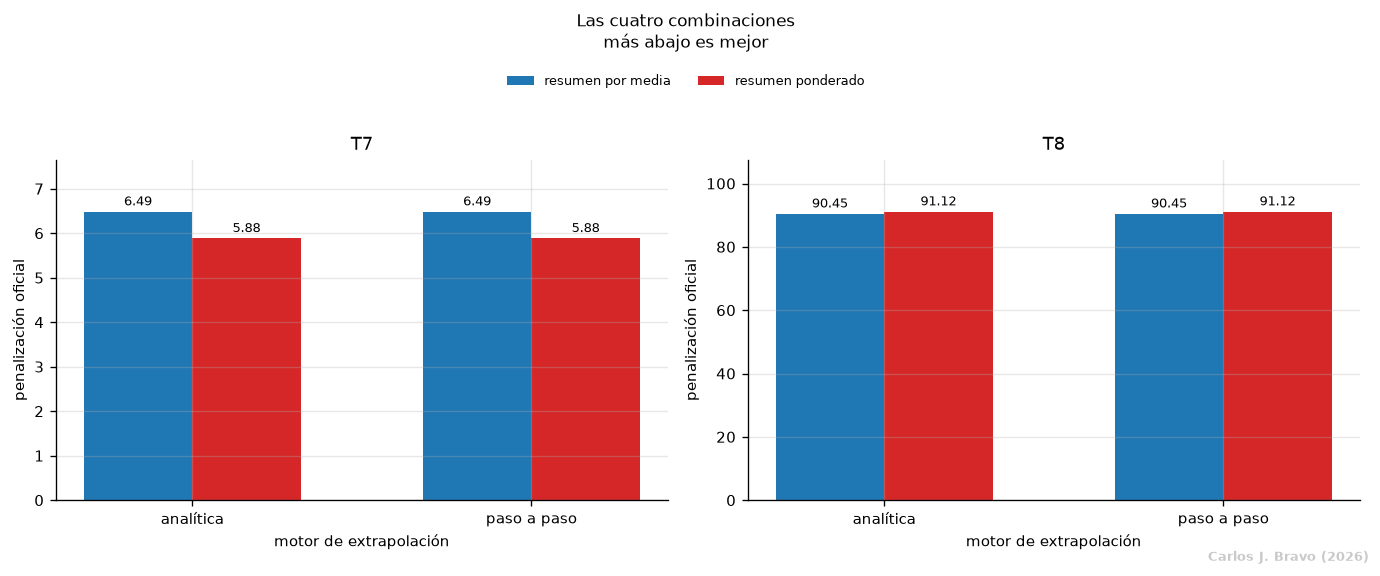

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, esp in zip(axes, ("T7", "T8")):
    t = tabla_contrastes(detalle, esp)
    x = np.arange(len(t.index)); ancho = 0.32
    b1 = ax.bar(x - ancho/2, t["media"], ancho, label="resumen por media", color="C0")
    b2 = ax.bar(x + ancho/2, t["ponderado"], ancho, label="resumen ponderado", color="C3")
    ax.bar_label(b1, fmt="%.2f", fontsize=7.5, padding=2)
    ax.bar_label(b2, fmt="%.2f", fontsize=7.5, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(t.index)
    ax.set(xlabel="motor de extrapolación", ylabel="penalización oficial", title=esp)
    ax.margins(y=.18)
fig.suptitle("Las cuatro combinaciones\nmás abajo es mejor", y=1.10, fontsize=10)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=2,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.0))
marca_de_agua(fig)
fig.tight_layout(); plt.show()

En las dos probetas las barras del mismo color quedan a la misma altura: cambiar de motor de
extrapolación no mueve nada. Lo único que separa alturas es el modo de resumir el latente, y en T8 ni
siquiera eso resulta apreciable a esta escala.

## 5. Aportación de cada componente y aportación conjunta

Con dos decisiones binarias, la aportación de una de ellas es la media de sus dos contrastes simples y
la aportación conjunta es la mitad de la diferencia entre esos dos contrastes. Signo negativo
significa mejora, porque la penalización baja.

In [7]:
for esp in ("T7", "T8"):
    print(f"\n{esp}")
    display(aportaciones(detalle, esp).round(4))

for esp in ("T7", "T8"):
    v = aportaciones(detalle, esp).set_index("término")["valor"]
    nulos = int((v.abs() < 1e-4).sum())
    print(f"\n{esp}: {nulos} de los {len(v)} términos son nulos hasta la precisión del integrador")
    for termino, valor in v.items():
        print(f"   {termino:34s} {valor:+12.8f}"
              f"{'   nulo' if abs(valor) < 1e-4 else ''}")


T7


,término,valor,detalle
0,(c) integración paso a paso,0.0000,"+0.000 con resumen por media, -0.000 con resum..."
1,(d) ponderación aprendida,-0.6004,"-0.600 con extrapolación analítica, -0.600 con..."
2,aportación conjunta de (c) y (d),-0.0000,mitad de la diferencia entre los dos contraste...



T8


,término,valor,detalle
0,(c) integración paso a paso,0.0000,"+0.000 con resumen por media, +0.000 con resum..."
1,(d) ponderación aprendida,0.6688,"+0.669 con extrapolación analítica, +0.669 con..."
2,aportación conjunta de (c) y (d),0.0000,mitad de la diferencia entre los dos contraste...



T7: 2 de los 3 términos son nulos hasta la precisión del integrador
   (c) integración paso a paso         +0.00000004   nulo
   (d) ponderación aprendida           -0.60040272
   aportación conjunta de (c) y (d)    -0.00000013   nulo

T8: 2 de los 3 términos son nulos hasta la precisión del integrador
   (c) integración paso a paso         +0.00000000   nulo
   (d) ponderación aprendida           +0.66880440
   aportación conjunta de (c) y (d)    +0.00000000   nulo


El término del predictor multi-paso y el de la aportación conjunta son nulos hasta la precisión del
integrador, que es lo que anticipaba el apartado 1 y lo que confirma que el conjunto de contrastes
está bien montado. El único término que no es nulo por construcción es el de la ponderación
aprendida, y el apartado siguiente delimita cuánto de él puede atribuirse al componente.

## 6. El recorrido entre semillas

El contraste de la ponderación cruza dos arquitecturas entrenadas por separado, de modo que su valor
incorpora la variación propia de cada una al cambiar la semilla. Las cuatro tandas dan esa medida.

In [8]:
filas = []
for k in range(N_TANDAS):
    d_k = {etiqueta: v for (etiqueta, kk), v in todo.items() if kk == k}
    for esp in ("T7", "T8"):
        v = aportaciones(d_k, esp).set_index("término")["valor"]
        filas.append({"tanda": k, "espécimen": esp,
                      "(c) integración paso a paso": round(float(v.iloc[0]), 6),
                      "(d) ponderación aprendida": round(float(v.iloc[1]), 4),
                      "aportación conjunta": round(float(v.iloc[2]), 6)})
recorrido = pd.DataFrame(filas)
display(recorrido)

for esp in ("T7", "T8"):
    d = recorrido.loc[recorrido["espécimen"] == esp, "(d) ponderación aprendida"]
    signo = "siempre negativo" if (d < 0).all() else (
        "siempre positivo" if (d > 0).all() else "cambia de signo entre tandas")
    print(f"{esp}: aportación de (d) entre {d.min():+.3f} y {d.max():+.3f}, {signo}")

,tanda,espécimen,(c) integración paso a paso,(d) ponderación aprendida,aportación conjunta
0,0,T7,0.0,-0.6004,-0.0
1,0,T8,0.0,0.6688,0.0
2,1,T7,0.0,0.6902,-0.0
3,1,T8,0.0,0.1231,0.0
4,2,T7,0.0,-0.3417,-0.0
5,2,T8,0.0,0.4881,0.0
6,3,T7,0.0,-1.9144,-0.0
7,3,T8,0.0,0.1855,0.0


T7: aportación de (d) entre -1.914 y +0.690, cambia de signo entre tandas
T8: aportación de (d) entre +0.123 y +0.669, siempre positivo


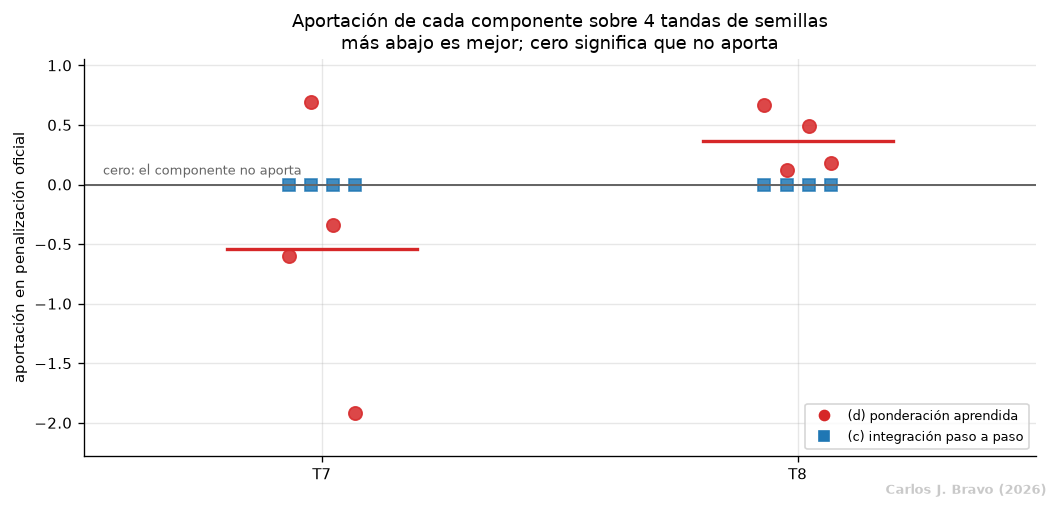

In [9]:
fig, ax = plt.subplots(figsize=(8.8, 4.2))
for x, esp in enumerate(("T7", "T8")):
    v = recorrido.loc[recorrido["espécimen"] == esp, "(d) ponderación aprendida"].to_numpy()
    ax.plot(np.full(len(v), x) + np.linspace(-.07, .07, len(v)), v, "o", color="C3", ms=8, alpha=.85)
    ax.plot([x - .2, x + .2], [v.mean()] * 2, color="C3", lw=2)
    w = recorrido.loc[recorrido["espécimen"] == esp, "(c) integración paso a paso"].to_numpy()
    ax.plot(np.full(len(w), x) + np.linspace(-.07, .07, len(w)), w, "s", color="C0", ms=7, alpha=.85)
ax.axhline(0.0, color="0.4", lw=1.2)
ax.annotate("cero: el componente no aporta", xy=(-0.46, 0.0), xytext=(0, 6),
            textcoords="offset points", fontsize=8, color="0.4", ha="left")
ax.plot([], [], "o", color="C3", label="(d) ponderación aprendida")
ax.plot([], [], "s", color="C0", label="(c) integración paso a paso")
ax.set_xticks([0, 1]); ax.set_xticklabels(["T7", "T8"])
ax.set(xlim=(-.5, 1.5), ylabel="aportación en penalización oficial",
       title=f"Aportación de cada componente sobre {N_TANDAS} tandas de semillas\n"
             "más abajo es mejor; cero significa que no aporta")
ax.legend(fontsize=8, loc="lower right")
ax.margins(y=.14)
marca_de_agua(fig)
fig.tight_layout(); plt.show()

El componente de integración paso a paso se apoya exactamente en cero en las cuatro tandas y en las
dos probetas, hasta la octava cifra decimal. No depende de la semilla porque la pareja que lo mide
comparte pesos, de modo que la medida es una identidad y no una estimación.

El de la ponderación aprendida se comporta de otra manera, y de un modo que decide la cuestión. Sobre
T7 no sólo se dispersa: cambia de signo entre tandas, de manera que en unas semillas el componente
mejora la penalización y en otras la empeora, y el recorrido es varias veces mayor que la media.
Sobre T8 mantiene el signo, pero es el signo contrario al deseado: empeora la penalización en las
cuatro tandas. No hay base para atribuir al componente una aportación favorable en ninguna de las dos
probetas.

## 7. Comparación con las Configuraciones 2 y 3

La Configuración 4 tiene dos configuraciones de referencia y se compara con ambas por separado.

In [10]:
filas = []
for base, anade in (("Config 2  (a+b+c)", "añade la ponderación aprendida"),
                    ("Config 3  (a+b+d)", "añade la integración paso a paso")):
    for esp in ("T7", "T8"):
        p4 = detalle["Config 4  (a+b+c+d)"][esp]["penalizacion"]
        pb = detalle[base][esp]["penalizacion"]
        filas.append({"referencia": base, "qué cambia": anade, "espécimen": esp,
                      "penalización de la referencia": round(pb, 4),
                      "penalización de la Configuración 4": round(p4, 4),
                      "diferencia": round(p4 - pb, 6)})
display(pd.DataFrame(filas))

,referencia,qué cambia,espécimen,penalización de la referencia,penalización de la Configuración 4,diferencia
0,Config 2 (a+b+c),añade la ponderación aprendida,T7,6.4853,5.8849,-0.600403
1,Config 2 (a+b+c),añade la ponderación aprendida,T8,90.4513,91.1201,0.668804
2,Config 3 (a+b+d),añade la integración paso a paso,T7,5.8849,5.8849,-0.000000
3,Config 3 (a+b+d),añade la integración paso a paso,T8,91.1201,91.1201,0.000000


Frente a la Configuración 3 la diferencia es nula: la Configuración 4 entrega exactamente la misma
curva, porque el componente que las separa no modifica la extrapolación. Frente a la Configuración 2
la diferencia es la del resumen del latente, y queda sujeta al recorrido del apartado 6.

## 8. El estudio de ablación completo

Las seis filas que el estudio produce, con las referencias del certamen junto a ellas. La penalización
oficial es directamente comparable por espécimen.

In [11]:
orden = ["Config 1  (a+b)", "Config 2  (a+b+c)", "Config 2b (a+b+c*)",
         "Config 3  (a+b+d)", "Config 4  (a+b+c+d)", "Config 4b (a+b+c*+d)"]
ablacion = pd.DataFrame([{
    "configuración": e,
    "pen T7": round(detalle[e]["T7"]["penalizacion"], 2),
    "pen T8": round(detalle[e]["T8"]["penalizacion"], 2),
    "total": round(detalle[e]["T7"]["penalizacion"] + detalle[e]["T8"]["penalizacion"], 2),
    "RMSE T7 (mm)": round(detalle[e]["T7"]["rmse"], 3),
    "RMSE T8 (mm)": round(detalle[e]["T8"]["rmse"], 3),
} for e in orden])
display(ablacion)

referencias = pd.DataFrame(
    [{"entrada": k, "T7": v["T7"], "T8": v["T8"], "total": v["total"],
      "naturaleza": "publicada"} for k, v in PUBLICADO.items()]
    + [{"entrada": f"{k}, réplica", "T7": v["T7"], "T8": v["T8"], "total": v["total"],
        "naturaleza": "reproducible"} for k, v in REPLICA.items()])
display(referencias.set_index("entrada"))

mejor = ablacion.loc[ablacion["total"].idxmin()]
print(f"Mejor total del estudio: {mejor['configuración']} con {mejor['total']:.2f}")
for k, v in REPLICA.items():
    print(f"  frente a {k}, réplica: T7 {mejor['pen T7']:.2f} contra {v['T7']:.2f} | "
          f"T8 {mejor['pen T8']:.2f} contra {v['T8']:.2f} | "
          f"total {mejor['total']:.2f} contra {v['total']:.2f}")
print(f"tiempo total del cuaderno: {(time.perf_counter()-INICIO)/60:.1f} min")

,configuración,pen T7,pen T8,total,RMSE T7 (mm),RMSE T8 (mm)
0,Config 1 (a+b),6.49,90.45,96.94,0.350,2.418
1,Config 2 (a+b+c),6.49,90.45,96.94,0.350,2.418
2,Config 2b (a+b+c*),6.49,90.45,96.94,0.350,2.418
3,Config 3 (a+b+d),5.88,91.12,97.00,0.522,2.431
4,Config 4 (a+b+c+d),5.88,91.12,97.00,0.522,2.431
5,Config 4b (a+b+c*+d),5.88,91.12,97.00,0.522,2.431


,T7,T8,total,naturaleza
entrada,,,,
1.º Youn et al. (2019),3.415,3.944,7.359,publicada
2.º Kong et al. (2020),3.543,4.088,7.631,publicada
3.º Rao et al. (2020),9.229,6.864,16.093,publicada
"1.º Youn et al. (2019), réplica",22.708,91.600,114.309,reproducible
"2.º Kong et al. (2020), réplica",83.252,148.344,231.596,reproducible
"3.º Rao et al. (2020), réplica",215.123,25.787,240.910,reproducible


Mejor total del estudio: Config 1  (a+b) con 96.94
  frente a 1.º Youn et al. (2019), réplica: T7 6.49 contra 22.71 | T8 90.45 contra 91.60 | total 96.94 contra 114.31
  frente a 2.º Kong et al. (2020), réplica: T7 6.49 contra 83.25 | T8 90.45 contra 148.34 | total 96.94 contra 231.60
  frente a 3.º Rao et al. (2020), réplica: T7 6.49 contra 215.12 | T8 90.45 contra 25.79 | total 96.94 contra 240.91
tiempo total del cuaderno: 13.5 min


La comparación con el certamen cierra el estudio, y conviene verla en la misma escala. La
Ilustración siguiente sitúa la mejor configuración frente a las tres referencias, cada una con su
valor publicado y con el que su réplica alcanza bajo idéntico protocolo.


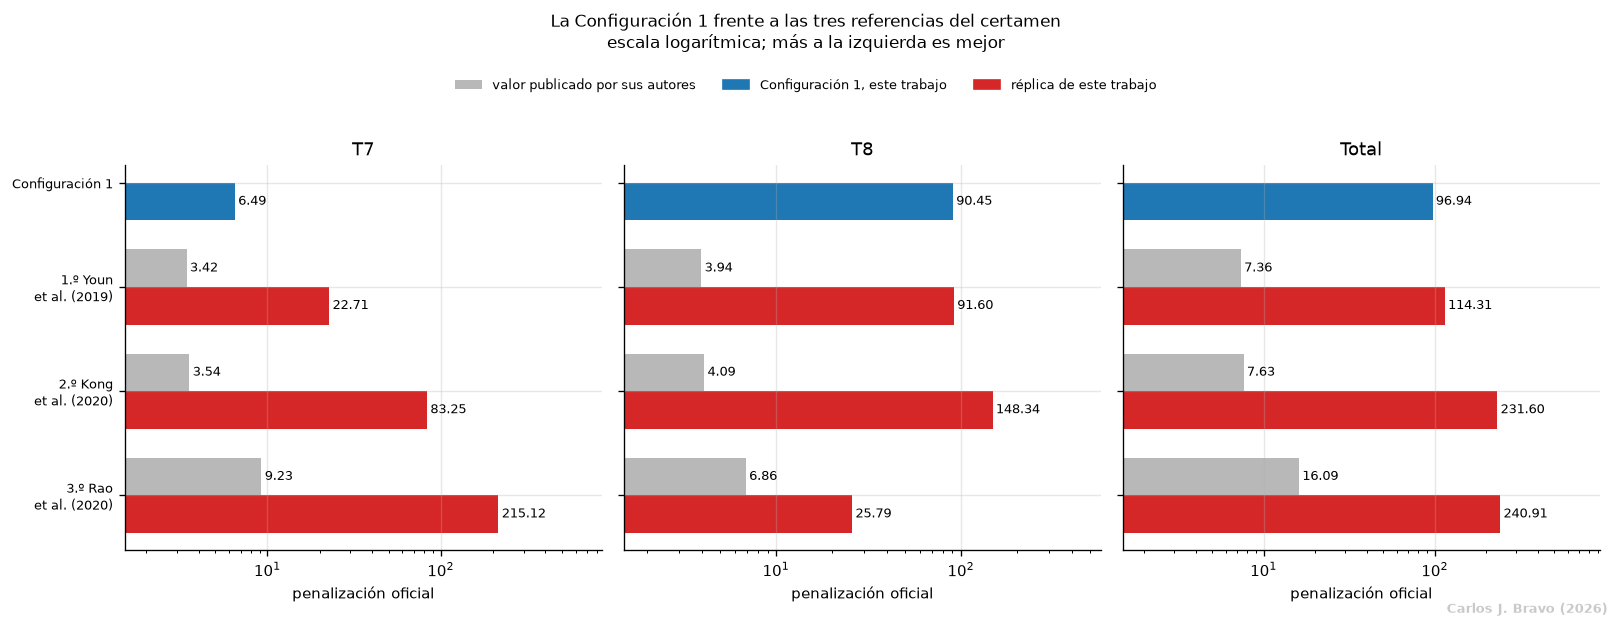

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharey=True)

METODOS = ["Configuración 1"] + list(PUESTOS)
pub = {"Configuración 1": None, **{k: PUBLICADO[k] for k in PUESTOS}}
rep = {"Configuración 1": {"T7": detalle["Config 1  (a+b)"]["T7"]["penalizacion"],
                           "T8": detalle["Config 1  (a+b)"]["T8"]["penalizacion"]},
       **{k: REPLICA[k] for k in PUESTOS}}
for v in rep.values():
    v["total"] = v["T7"] + v["T8"]

y = np.arange(len(METODOS))[::-1]
alto = 0.36
for ax, clave in zip(axes, ("T7", "T8", "total")):
    vp = [pub[m][clave] if pub[m] else np.nan for m in METODOS]
    vr = [rep[m][clave] for m in METODOS]
    b1 = ax.barh(y + alto/2, vp, alto, color="0.72", label="valor publicado por sus autores")
    b2 = ax.barh(y - alto/2, vr, alto,
                 color=["C0"] + ["C3"] * len(PUESTOS))
    ax.bar_label(b1, fmt="%.2f", fontsize=7.5, padding=2)
    ax.bar_label(b2, fmt="%.2f", fontsize=7.5, padding=2)
    ax.set_xscale("log")
    ax.set_xlim(1.5, ax.get_xlim()[1] * 3.2)
    ax.set(xlabel="penalización oficial", title="Total" if clave == "total" else clave)
    ax.grid(axis="x", alpha=.3)

axes[0].set_yticks(y)
axes[0].set_yticklabels([m.replace(" et al.", "\net al.") for m in METODOS], fontsize=8)
fig.suptitle("La Configuración 1 frente a las tres referencias del certamen\n"
             "escala logarítmica; más a la izquierda es mejor", y=1.10, fontsize=10)
manijas, etiquetas = axes[0].get_legend_handles_labels()
manijas += [plt.Rectangle((0, 0), 1, 1, color="C0"),
            plt.Rectangle((0, 0), 1, 1, color="C3")]
etiquetas += ["Configuración 1, este trabajo", "réplica de este trabajo"]
fig.legend(manijas, etiquetas, loc="upper center", ncol=3,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, 1.0))
marca_de_agua(fig)
fig.tight_layout(); plt.show()


La figura separa lo que las dos tablas mezclan. Frente a lo **reproducible**, que es la comparación
legítima porque ambas columnas salen del mismo protocolo, la Configuración 1 gana en T7 y en el total
a las tres réplicas, y en T8 a dos de las tres. Frente a lo **publicado** pierde con claridad, y la
distancia procede entera de T8: en T7 su penalización es del mismo orden que la de los ganadores.


## 9. Conclusiones

1. **La integración paso a paso no aporta nada, ni sola ni combinada.** Su término y el de la
   aportación conjunta son nulos hasta la precisión del integrador, y lo son de forma exacta en las
   cuatro tandas porque las parejas que los miden comparten pesos. Es el resultado que el apartado 1
   anticipaba, y confirma que el conjunto de contrastes está bien montado.
2. **El único término que no es nulo por construcción es el de la ponderación aprendida, y no
   sobrevive al cambio de semilla.** Sobre T7 cambia de signo entre tandas, con un recorrido varias
   veces mayor que su media, de modo que el componente mejora la penalización en unas semillas y la
   empeora en otras. Sobre T8 conserva el signo, pero es el contrario al deseado: empeora la
   penalización en las cuatro tandas.
3. **La Configuración 4 coincide exactamente con la Configuración 3.** El componente que las separa no
   modifica la curva entregada, de modo que combinar los dos componentes no produce ninguna
   configuración nueva en términos de resultado.
4. **Ninguna de las seis filas del estudio mejora a la Configuración 1 de forma atribuible a su
   componente añadido**, y el mejor total del estudio corresponde a la propia Configuración 1. En la
   penalización oficial, que es la métrica del certamen y la directamente comparable con las tablas
   de clasificación, el estudio de ablación concluye que los componentes añadidos no aportan.
5. **El valor del estudio no está en el orden de las filas sino en localizar el límite.** Las
   Configuraciones 2 y 3 fallan en T8 por razones independientes, una por el techo estructural de su
   mecanismo y otra porque la información no está en la entrada, y la 4 hereda ambas.

## 10. Limitaciones

* **El contraste del motor de extrapolación es exacto** porque las parejas comparten pesos, pero **el
  del resumen del latente cruza arquitecturas entrenadas por separado** y arrastra la variación de
  ambas. Es la razón de que se reporte con su recorrido y no como una cifra única.
* **El recorrido se mide sobre cuatro tandas**, suficiente para descartar las diferencias que quedan
  dentro de él pero no para estimar con precisión las que queden fuera.
* **La cota de extrapolación, heredada de la Configuración 1, fija la magnitud de la curva entregada
  en T8** en todas las filas. Ordenar configuraciones por su penalización en T8 ordena dónde cae el
  recorte y no la calidad del motor.
* **Ningún espécimen de entrenamiento es de amplitud variable**, de modo que ni la interacción de
  cargas ni el cambio de régimen pueden validarse con este conjunto de datos.

## Los pesos entrenados

Los conjuntos que este cuaderno ha usado quedan guardados en `models/`, de modo que una ejecución
posterior los carga en lugar de repetir el entrenamiento. Como la siembra está fijada, cargar y
reentrenar producen los mismos pesos bit a bit; lo que cambia es el tiempo.


In [13]:
print(inventario())


50 conjuntos en models/
  comparativo/arquitectura_media      5 modelos  cnn_pinn                 81 s    0.3 MB
  comparativo/arquitectura_ponderado  5 modelos  cnn_attention_pinn      120 s    0.5 MB
  comparativo/dourado_certamen        5 modelos  cnn_pinn                 82 s    0.3 MB
  comparativo/dourado_sin_T1          3 modelos  cnn_pinn                 42 s    0.2 MB
  comparativo/dourado_sin_T3          3 modelos  cnn_pinn                 41 s    0.2 MB
  comparativo/dourado_sin_T4          3 modelos  cnn_pinn                 40 s    0.2 MB
  comparativo/dourado_sin_T6          3 modelos  cnn_pinn                 42 s    0.2 MB
  comparativo/forman_certamen         5 modelos  cnn_pinn                 84 s    0.3 MB
  comparativo/forman_sin_T1           3 modelos  cnn_pinn                 42 s    0.2 MB
  comparativo/forman_sin_T3           3 modelos  cnn_pinn                 41 s    0.2 MB
  comparativo/forman_sin_T4           3 modelos  cnn_pinn                 42 s    0.2 